In [6]:
import pandas as pd

# Load the dataset
file_path = r'C:\Users\moses_y\OneDrive\Desktop\ML Projects\Log Loss\train_data_swc.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataframe and basic information
data.head(), data.info(), data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62500 entries, 0 to 62499
Columns: 109 entries, x_1 to y
dtypes: float64(108), int64(1)
memory usage: 52.0 MB


(   x_1  x_2  x_3  x_4  x_5  x_6  x_7  x_8  x_9  x_10  ...  x_100  x_101  \
 0  0.0  0.0  0.0  0.2  0.0  0.0  0.0  0.0  0.0   0.0  ...    0.0    0.0   
 1  0.2  0.8  0.0  0.0  0.0  0.0  0.6  0.2  0.0   0.0  ...    0.2    0.0   
 2  0.0  0.0  0.0  0.4  0.0  0.0  3.2  0.0  0.0   0.0  ...    0.0    0.0   
 3  0.0  0.0  0.2  0.0  0.0  0.0  0.2  0.0  0.0   0.0  ...    0.0    0.0   
 4  0.0  0.0  0.4  0.0  0.0  0.0  0.4  0.0  0.0   0.6  ...    0.0    0.0   
 
    x_102  x_103  x_104  x_105  x_106  x_107  x_108  y  
 0    0.2    0.0    0.0    0.0    0.0    0.0    0.0  3  
 1    0.8    0.0    0.0    0.0    0.0    0.0    0.0  9  
 2    0.6    0.0    0.0    0.0    0.0    0.0    0.0  3  
 3    0.0    0.0    0.0    0.0    0.0    0.0    0.0  3  
 4    0.0    0.6    0.2    0.0    0.0    0.2    0.0  9  
 
 [5 rows x 109 columns],
 None,
                 x_1           x_2           x_3           x_4           x_5  \
 count  62500.000000  62500.000000  62500.000000  62500.000000  62500.000000   
 mean 

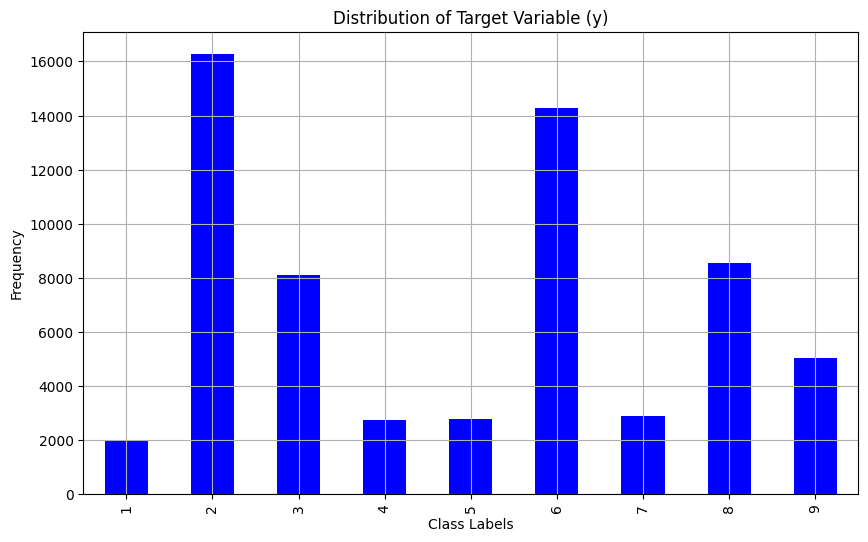

In [7]:
import matplotlib.pyplot as plt

# Check the distribution of the target variable
plt.figure(figsize=(10, 6))
data['y'].value_counts().sort_index().plot(kind='bar', color='blue')
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


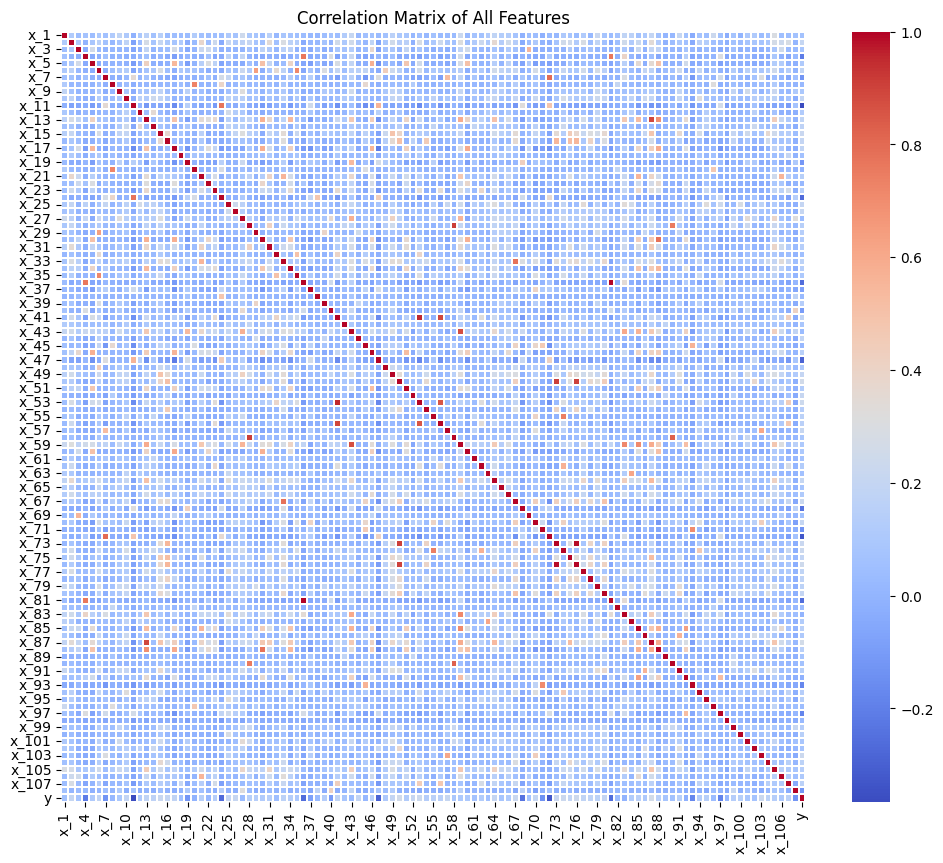

In [8]:
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = data.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap
sns.heatmap(correlation_matrix, cmap='coolwarm', linewidths=0.1, linecolor='white')
plt.title('Correlation Matrix of All Features')
plt.show()


In [9]:
# Identifying strong correlations with the target variable 'y'
correlations_with_y = correlation_matrix['y'].sort_values(ascending=False)

# Displaying the top correlations with 'y'
strong_correlations = correlations_with_y[abs(correlations_with_y) > 0.1]  # Filtering to show stronger correlations
strong_correlations


y       1.000000
x_87    0.261362
x_50    0.253853
x_76    0.241530
x_53    0.235274
          ...   
x_81   -0.258775
x_24   -0.265928
x_47   -0.293908
x_72   -0.330005
x_11   -0.365018
Name: y, Length: 81, dtype: float64

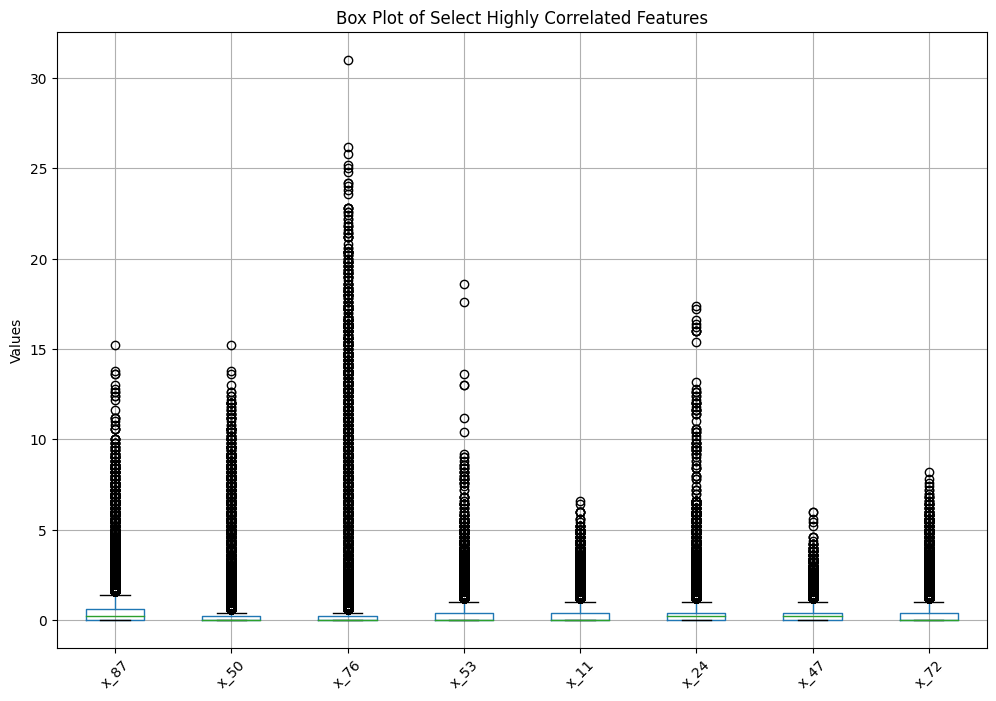

In [10]:
# Selecting top positively and negatively correlated features to plot
features_to_plot = ['x_87', 'x_50', 'x_76', 'x_53', 'x_11', 'x_24', 'x_47', 'x_72']

# Creating box plots for these features
plt.figure(figsize=(12, 8))
data[features_to_plot].boxplot()
plt.title('Box Plot of Select Highly Correlated Features')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [11]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Selecting numerical features for scaling
numerical_features = data.columns[:-1]  # Excluding the target variable 'y'

# Fitting the scaler to the data and transforming it
data_scaled = data.copy()
data_scaled[numerical_features] = scaler.fit_transform(data[numerical_features])

# Display the first few rows of the scaled data to verify the transformation
data_scaled.head()


,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_100,x_101,x_102,x_103,x_104,x_105,x_106,x_107,x_108,y
0,0.000000,0.000,0.000000,0.033333,0.0,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.016393,0.000000,0.000000,0.0,0.0,0.000000,0.0,3
1,0.026316,0.125,0.000000,0.000000,0.0,0.0,0.039474,0.011494,0.0,0.000000,...,0.019231,0.0,0.065574,0.000000,0.000000,0.0,0.0,0.000000,0.0,9
2,0.000000,0.000,0.000000,0.066667,0.0,0.0,0.210526,0.000000,0.0,0.000000,...,0.000000,0.0,0.049180,0.000000,0.000000,0.0,0.0,0.000000,0.0,3
3,0.000000,0.000,0.020833,0.000000,0.0,0.0,0.013158,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,3
4,0.000000,0.000,0.041667,0.000000,0.0,0.0,0.026316,0.000000,0.0,0.041667,...,0.000000,0.0,0.000000,0.035714,0.012658,0.0,0.0,0.033333,0.0,9


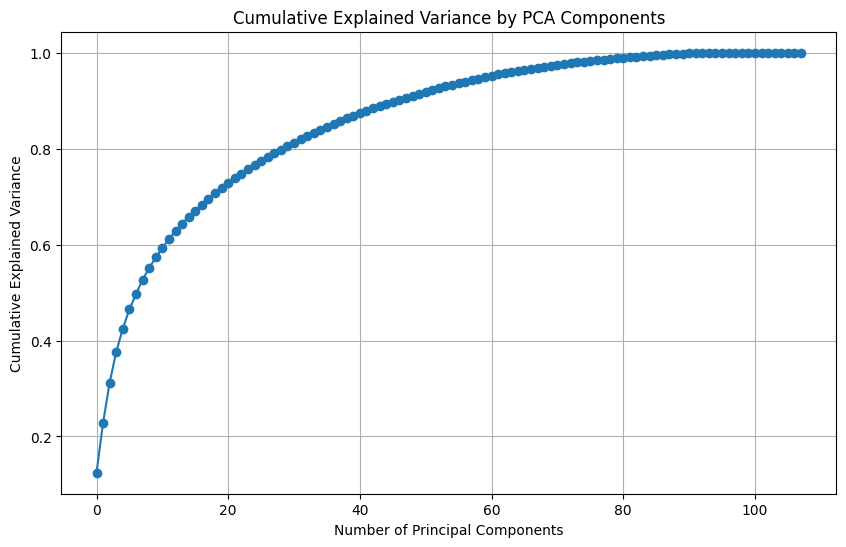

In [12]:
from sklearn.decomposition import PCA

# Initialize PCA
pca = PCA()

# Fitting PCA on the scaled numerical features (excluding target variable)
pca.fit(data_scaled[numerical_features])

# Cumulative explained variance ratio
cumulative_explained_variance = pca.explained_variance_ratio_.cumsum()

# Plotting the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(cumulative_explained_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()


In [13]:
# Find the number of components that capture at least 90% of the variance
components_90_percent = (cumulative_explained_variance >= 0.97).argmax() + 1

# Apply PCA with the selected number of components
pca_90 = PCA(n_components=components_90_percent)
data_pca_90 = pca_90.fit_transform(data_scaled[numerical_features])

# Display the shape of the new data and the number of components used
data_pca_90.shape, components_90_percent


((62500, 69), 69)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss

# Preparing the target variable and feature set
X = data_pca_90
y = data_scaled['y']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initializing the models
logistic_model = LogisticRegression(max_iter=1500, random_state=42)
random_forest_model = RandomForestClassifier(n_estimators=200, max_depth=30, min_samples_split=15, random_state=42)

# Training Logistic Regression
logistic_model.fit(X_train, y_train)
logistic_predictions_proba = logistic_model.predict_proba(X_test)

# Training Random Forest
random_forest_model.fit(X_train, y_train)
random_forest_predictions_proba = random_forest_model.predict_proba(X_test)

# Calculating log loss for each model
log_loss_logistic = log_loss(y_test, logistic_predictions_proba)
log_loss_random_forest = log_loss(y_test, random_forest_predictions_proba)

log_loss_logistic, log_loss_random_forest


(0.7500806980772957, 0.699017367489567)

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, GaussianNoise, BatchNormalization, Activation
from keras.optimizers import Adam
from sklearn.metrics import log_loss
from keras.callbacks import ReduceLROnPlateau

# Load and preprocess data
data = pd.read_csv(r"C:\Users\moses_y\OneDrive\Desktop\ML Projects\Log Loss\train_data_swc.csv").dropna()

# Feature and target extraction
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
y -= 1  # Subtract 1 from each class label to shift from [1,9] to [0,8]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Calculate the target number of samples per class
class_counts = y_train.value_counts()
target_num_samples = max(class_counts.max(), int((class_counts.max() + class_counts.min()) / 2))

# Handling class imbalance with SMOTE
# Ensure that we only increase the number of samples in minority classes
smote_strategy = {class_id: target_num_samples for class_id in np.unique(y_train) if class_counts[class_id] < target_num_samples}
smote = SMOTE(sampling_strategy=smote_strategy)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# Neural Network for Meta Model
meta_model = Sequential([
    Dense(1024, input_dim=X_train_scaled.shape[1]),
    BatchNormalization(),
    Activation('elu'),
    Dropout(0.3),
    Dense(512),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    Dense(len(np.unique(y)), activation='softmax')
])

meta_model.compile(optimizer=Adam(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Learning Rate Scheduler
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

# Fit model
meta_model.fit(X_train_scaled, y_train_sm, epochs=100, batch_size=32, verbose=1, 
               validation_data=(X_test_scaled, y_test), callbacks=[reduce_lr])

# Final validation
preds_test = meta_model.predict(X_test_scaled)
final_log_loss = log_loss(y_test, preds_test)
print(f"Final log loss: {final_log_loss}")


Epoch 1/100
3228/3228 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.6616 - loss: 0.9075 - val_accuracy: 0.7097 - val_loss: 0.7248 - learning_rate: 0.0100
Epoch 2/100
 816/3228 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.7324 - loss: 0.7160

KeyboardInterrupt: 

Using device: cpu
[16:52:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

[16:53:08] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

[16:53:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

[16:53:25] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

[16:53:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

[1

[I 2024-05-14 17:47:11,094] A new study created in memory with name: no-name-92e99414-7578-4fd9-932a-45b1acb2a06b
[I 2024-05-14 17:47:46,544] Trial 0 finished with value: -0.49951476913954734 and parameters: {'feature_fraction': 0.2064151629092475, 'bagging_fraction': 0.5102944789127726, 'learning_rate': 0.048808066077357375, 'colsample_bytree': 0.7427211366968914}. Best is trial 0 with value: -0.49951476913954734.
[I 2024-05-14 17:48:10,854] Trial 1 finished with value: -0.49382710270008434 and parameters: {'feature_fraction': 0.3955261166810148, 'bagging_fraction': 0.14341940803064165, 'learning_rate': 0.022928850978322042, 'colsample_bytree': 0.448272252333074}. Best is trial 1 with value: -0.49382710270008434.
[I 2024-05-14 17:48:27,269] Trial 2 finished with value: -0.49569535417973504 and parameters: {'feature_fraction': 0.3245715639692951, 'bagging_fraction': 0.6981978282655416, 'learning_rate': 0.042847408421756904, 'colsample_bytree': 0.38077843466288386}. Best is trial 1 with

[LightGBM] [Warning] feature_fraction is set=0.4665239383316811, colsample_bytree=0.6321854214763306 will be ignored. Current value: feature_fraction=0.4665239383316811
[LightGBM] [Warning] bagging_fraction is set=0.6263908229194499, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6263908229194499
[LightGBM] [Warning] feature_fraction is set=0.4665239383316811, colsample_bytree=0.6321854214763306 will be ignored. Current value: feature_fraction=0.4665239383316811
[LightGBM] [Warning] bagging_fraction is set=0.6263908229194499, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6263908229194499
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040538 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40613
[LightGBM] [Info] Number of data points in the train set: 8750, number of used features: 264
[LightGBM] [Info] Start training from score -3.575551
[LightGBM] [Info] Start 

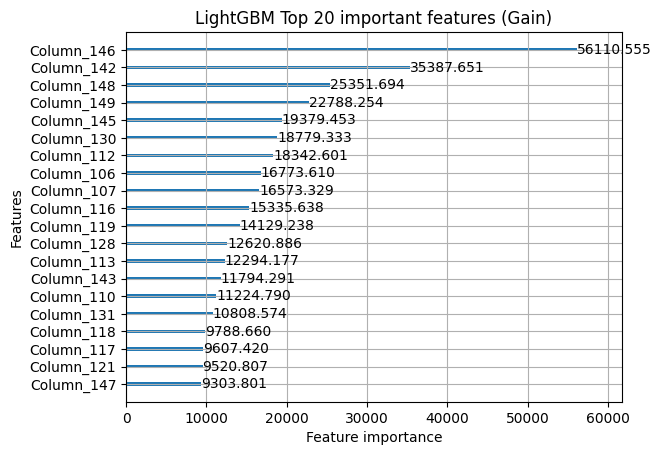

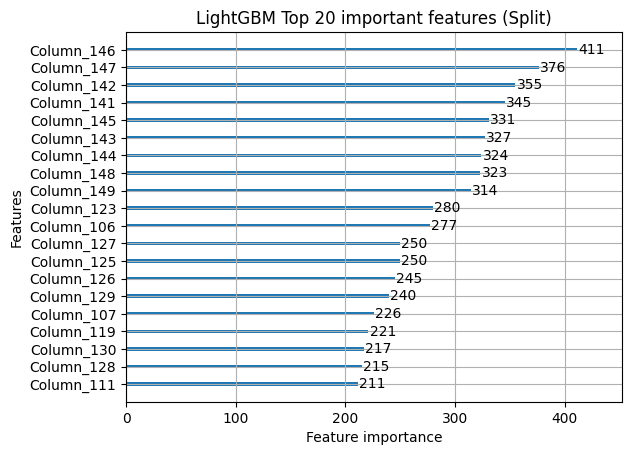

In [23]:
#!pip install pytorch_tabnet
#!pip install xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.utils import resample, shuffle, class_weight
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, plot_importance
from keras.models import Sequential, Model
from keras.layers import Dense, GaussianNoise, Input, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras import regularizers
from keras.callbacks import ReduceLROnPlateau
from statsmodels.stats.outliers_influence import variance_inflation_factor
import optuna
from pytorch_tabnet.tab_model import TabNetClassifier
import warnings
warnings.filterwarnings("ignore")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Constants for training
ae_epoch, nn_epoch, lg_max_iter, tn_max_epochs, optuna_n_trials = 70, 70, 400, 150, 20

# Functions for feature engineering
# def calculate_vif(X, thresh=95):
#     cols = X.columns
#     variables = np.arange(X.shape[1])
#     dropped = True
#     while dropped:
#         dropped = False
#         c = X[cols[variables]].values
#         vif = [variance_inflation_factor(c, ix) for ix in np.arange(c.shape[1])]
#         maxloc = vif.index(max(vif))
#         if max(vif) > thresh:
#             print('dropping \'' + X[cols[variables]].columns[maxloc] + '\' at index: ' + str(maxloc))
#             variables = np.delete(variables, maxloc)
#             dropped = True
#     print('Remaining variables:')
#     print(X.columns[variables])
#     return X[cols[variables]]

def remove_highly_correlated_features(df, threshold=0.95):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

# Define Autoencoder

def get_autoencoder(X_train_scaled):
    input_dim=X_train_scaled.shape[1]
    input_layer = Input(shape=(input_dim, ))
    encoder = Dense(128, activation="elu", activity_regularizer=regularizers.l1(0.001))(input_layer)
    encoder = Dense(64, activation="relu")(encoder)
    decoder = Dense(64, activation='relu')(encoder)
    decoder = Dense(128, activation='relu')(decoder)
    output_layer = Dense(input_dim, activation='elu')(decoder)
    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    
    autoencoder.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error', metrics=['accuracy'])
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)
    autoencoder.fit(X_train_scaled, X_train_scaled, epochs=ae_epoch, batch_size=32, shuffle=True, verbose=1, callbacks=[reduce_lr])
    return autoencoder
    
# Load and prepare data

train_data = pd.read_csv(r"C:\Users\moses_y\OneDrive\Desktop\ML Projects\Log Loss\train_data_swc.csv").dropna()
#train_data, to_drop = remove_highly_correlated_features(train_data)

X = train_data.drop('y', axis=1)
y = train_data['y'] - 1

# Split data into training, validation, and test sets first
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)  # Reserving 20% for temp split
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # Splitting the 20% into two parts for validation and test


# Resampling the training data to handle class imbalance
class_size = 8000  # Adjust based on your class distribution and needs
resampled_data = []
for label in np.unique(y_train):
    label_data = X_train[y_train == label]
    if len(label_data) < class_size:
        resampled_features = resample(label_data, replace=True, n_samples=class_size, random_state=42)
        resampled_labels = np.full(class_size, label)
    else:
        resampled_features = resample(label_data, replace=False, n_samples=class_size, random_state=42)
        resampled_labels = np.full(class_size, label)
    resampled_data.append((resampled_features, resampled_labels))

X_train_resampled = pd.concat([data[0] for data in resampled_data])
y_train_resampled = np.concatenate([data[1] for data in resampled_data])

# Shuffle the resampled data to mix up the classes
X_train_resampled, y_train_resampled = shuffle(X_train_resampled, y_train_resampled, random_state=42)

# Correct the labels used for training after resampling
#y_train = y_train_resampled  # Ensure you use the resampled labels

# Feature engineering on training data only
X_train, to_drop_train = remove_highly_correlated_features(X_train, threshold=0.95)
#X_train = calculate_vif(X_train, thresh=95)

# Apply the same feature transformation to validation and test sets
X_valid = X_valid.drop(columns=to_drop_train)
X_test = X_test.drop(columns=to_drop_train)
X_valid = X_valid[X_train.columns]  # Ensure validation set has same columns as training set after dropping
X_test = X_test[X_train.columns]    # Ensure test set has same columns as training

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)


# Initialize and train models
tn = TabNetClassifier(device_name=device, optimizer_params=dict(lr=0.0025), scheduler_params={"step_size":10, "gamma":1.3}, scheduler_fn=torch.optim.lr_scheduler.StepLR, verbose=0)
rf = RandomForestClassifier(n_estimators=198, random_state=42)
et = ExtraTreesClassifier(n_estimators= 170, criterion = "gini")
lg = LogisticRegression(
    random_state = 42,
    solver = "lbfgs",
    max_iter = lg_max_iter,
    multi_class = "auto",
    verbose = 0
    )
nn = Sequential([
    GaussianNoise(0.001),
    Dense(1024, activation='elu', input_dim=X_train_scaled.shape[1]),
    BatchNormalization(),
    Dropout(0.29),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.29),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.29),
    Dense(128, activation='sigmoid'),
    BatchNormalization(),
    Dropout(0.29),
    Dense(len(np.unique(y)), activation='softmax')
])
nn.compile(optimizer=Adam(learning_rate=0.00025), loss='sparse_categorical_crossentropy')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00005)

# Initialize and train XGBoost
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    tree_method='hist',
    device='cuda'
)
params_xgb = {
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.1, 0.4, 1.0],
    'colsample_bytree': [0.2, 0.8, 1.0],
    'n_estimators': [170, 200],
    'learning_rate': [0.01, 0.05, 0.1]
}
randomxgb = RandomizedSearchCV(xgb, params_xgb, n_iter=25, scoring='neg_log_loss', cv=5, random_state=42)

randomxgb.fit(X_train_scaled, y_train)
tn.fit(X_train_scaled, y_train, eval_set=[(X_valid_scaled, y_valid)], max_epochs=tn_max_epochs, eval_metric=['logloss'])
nn.fit(X_train_scaled, y_train, epochs=nn_epoch, batch_size=32, validation_data=(X_valid_scaled, y_valid), callbacks=[reduce_lr])
rf.fit(X_train_scaled, y_train)
et.fit(X_train_scaled, y_train)
lg.fit(X_train_scaled, y_train)


# Evaluate models
#print("AE log loss:", log_loss(y_valid, autoencoder.predict(X_valid_scaled)))
print("RF log loss:", log_loss(y_valid, rf.predict_proba(X_valid_scaled)))
print("ET log loss:", log_loss(y_valid, et.predict_proba(X_valid_scaled)))
print("LG log loss:", log_loss(y_valid, lg.predict_proba(X_valid_scaled)))
print("XGBoost log loss:", log_loss(y_valid, randomxgb.predict_proba(X_valid_scaled)))
print("NN log loss:", log_loss(y_valid, nn.predict(X_valid_scaled)))
print("TN log loss:", log_loss(y_valid, tn.predict_proba(X_valid_scaled)))


# Generate probabilities for the validation and test sets
rf_probs_val = rf.predict_proba(X_valid_scaled)
rf_probs_test = rf.predict_proba(X_test_scaled)

et_probs_val = et.predict_proba(X_valid_scaled)
et_probs_test = et.predict_proba(X_test_scaled)

lg_probs_val = lg.predict_proba(X_valid_scaled)
lg_probs_test = lg.predict_proba(X_test_scaled)


nn_probs_val = nn.predict(X_valid_scaled)
nn_probs_test = nn.predict(X_test_scaled)

tn_probs_val = tn.predict_proba(X_valid_scaled)
tn_probs_test = tn.predict_proba(X_test_scaled)

#XGBoost probabilities
xgb_probs_val = randomxgb.predict_proba(X_valid_scaled)
xgb_probs_test = randomxgb.predict_proba(X_test_scaled)

# Autoencoder for dimensionality reduction
autoencoder = get_autoencoder(X_train_scaled)

# Use the encoder part of the autoencoder to transform the data
ae_features_train = autoencoder.predict(X_train_scaled)
ae_features_val = autoencoder.predict(X_valid_scaled)
ae_features_test = autoencoder.predict(X_test_scaled)


# Stack probabilities for meta-model training
stacked_features_val = np.column_stack((X_valid_scaled, rf_probs_val, et_probs_val, xgb_probs_val, lg_probs_val, nn_probs_val, tn_probs_val, ae_features_val))
# Generate stacked features for the test set
stacked_features_test = np.column_stack((X_test_scaled, rf_probs_test, et_probs_test, xgb_probs_test, lg_probs_test, nn_probs_test, tn_probs_test, ae_features_test))

# Evaluate and tune model using Optuna
def objective(trial):
    params = {
        'objective': 'multiclass',
        'num_class': len(np.unique(y)),
        'metric': 'multi_logloss',
        'boosting_type': 'gbdt',
        'feature_fraction': trial.suggest_uniform('feature_fraction', 0.1, 0.65),
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.1, 0.75),
        'learning_rate': trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        'colsample_bytree': trial.suggest_float("colsample_bytree", 0.1, 0.9)
        }
    lgbm = LGBMClassifier(**params)
    return cross_val_score(lgbm, stacked_features_val, y_valid, n_jobs=-1, cv=KFold(5), scoring='neg_log_loss').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=optuna_n_trials)

# Train the final model with the best hyperparameters
params = study.best_params
meta_model = LGBMClassifier(**params)
meta_model.fit(stacked_features_val, y_valid)


# Final evaluation
final_log_loss_val = log_loss(y_valid, meta_model.predict_proba(stacked_features_val))
final_log_loss_test = log_loss(y_test, meta_model.predict_proba(stacked_features_test))


# Final validation
preds_valid = meta_model.predict_proba(stacked_features_val)
preds_test = meta_model.predict_proba(stacked_features_test)

print(f"Final log loss: {log_loss(y_valid, preds_valid)}")
print(f"Final log loss: {log_loss(y_test, preds_test)}")

print(f"Meta Model Final log loss on validation set: {final_log_loss_val}")
print(f"Meta Model Final log loss on test set: {final_log_loss_test}")

plot_importance(meta_model, max_num_features=20, importance_type="gain", title="LightGBM Top 20 important features (Gain)")
plt.show()
plot_importance(meta_model, max_num_features=20, importance_type="split", title="LightGBM Top 20 important features (Split)")
plt.show()



['x_76', 'x_81']
{1: 1954, 2: 16283, 3: 8089, 4: 2718, 5: 2763, 6: 14264, 7: 2874, 8: 8540, 9: 5015}
epoch 0  | loss: 1.77755 | val_0_logloss: 1.39242 |  0:00:05s
epoch 1  | loss: 1.21876 | val_0_logloss: 1.09639 |  0:00:10s
epoch 2  | loss: 1.03376 | val_0_logloss: 0.9379  |  0:00:16s
epoch 3  | loss: 0.90386 | val_0_logloss: 0.82839 |  0:00:21s
epoch 4  | loss: 0.83129 | val_0_logloss: 0.77989 |  0:00:26s
epoch 5  | loss: 0.77176 | val_0_logloss: 0.72739 |  0:00:31s
epoch 6  | loss: 0.73443 | val_0_logloss: 0.72163 |  0:00:36s
epoch 7  | loss: 0.7088  | val_0_logloss: 0.69163 |  0:00:42s
epoch 8  | loss: 0.69191 | val_0_logloss: 0.66847 |  0:00:47s
epoch 9  | loss: 0.67661 | val_0_logloss: 0.6699  |  0:00:52s
epoch 10 | loss: 0.66106 | val_0_logloss: 0.67099 |  0:00:57s
epoch 11 | loss: 0.65691 | val_0_logloss: 0.64971 |  0:01:03s
epoch 12 | loss: 0.645   | val_0_logloss: 0.64054 |  0:01:08s
epoch 13 | loss: 0.63739 | val_0_logloss: 0.62437 |  0:01:13s
epoch 14 | loss: 0.63644 | val_

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,376 (36.62 KB)

 Trainable params: 9,376 (36.62 KB)

 Non-trainable params: 0 (0.00 B)

None
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[-0.27902063 -0.42181169 -0.17146213 ...  0.23146075  0.39448464
   0.26738816]
 [-0.27902063 -0.42181169 -0.17146213 ...  0.27666947  0.26620546
  -0.05617875]
 [-0.27902063  0.32558665 -0.17146213 ... -0.18471527  1.70074224
   0.54069322]
 ...
 [-0.27902063  0.32558665 -0.17146213 ... -0.02904958  0.23369427
  -0.0072943 ]
 [-0.27902063  0.32558665 -0.17146213 ...  0.34386447  0.66931039
   0.08096406]
 [-0.27902063  0.32558665 -0.17146213 ...  0.47708347  0.39036888
   0.50478351]]


[I 2024-05-13 08:49:41,997] A new study created in memory with name: no-name-0061a2b0-5414-4003-9ba5-3f25ee5c89c8
[I 2024-05-13 08:49:59,730] Trial 0 finished with value: -1.4033556267529503 and parameters: {'feature_fraction': 0.9578275043223317, 'bagging_fraction': 0.5159065520208945, 'learning_rate': 0.0016833897606318424, 'colsample_bytree': 0.4425494799592041}. Best is trial 0 with value: -1.4033556267529503.
[I 2024-05-13 08:50:14,001] Trial 1 finished with value: -0.4966842443670214 and parameters: {'feature_fraction': 0.5722062567518307, 'bagging_fraction': 0.8149381204553352, 'learning_rate': 0.040275477767992215, 'colsample_bytree': 0.5611500137088424}. Best is trial 1 with value: -0.4966842443670214.
[I 2024-05-13 08:50:28,045] Trial 2 finished with value: -0.9938034475652767 and parameters: {'feature_fraction': 0.8630275153684809, 'bagging_fraction': 0.9049410323599427, 'learning_rate': 0.0044209014797133295, 'colsample_bytree': 0.38306585152204525}. Best is trial 1 with va

[LightGBM] [Warning] feature_fraction is set=0.48671265951426684, colsample_bytree=0.6153816025830104 will be ignored. Current value: feature_fraction=0.48671265951426684
[LightGBM] [Warning] bagging_fraction is set=0.6729240029456464, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6729240029456464
[LightGBM] [Warning] feature_fraction is set=0.48671265951426684, colsample_bytree=0.6153816025830104 will be ignored. Current value: feature_fraction=0.48671265951426684
[LightGBM] [Warning] bagging_fraction is set=0.6729240029456464, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6729240029456464
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029743 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20955
[LightGBM] [Info] Number of data points in the train set: 9375, number of used features: 199
[LightGBM] [Info] Start training from score -3.562306
[LightGBM] [Info] St

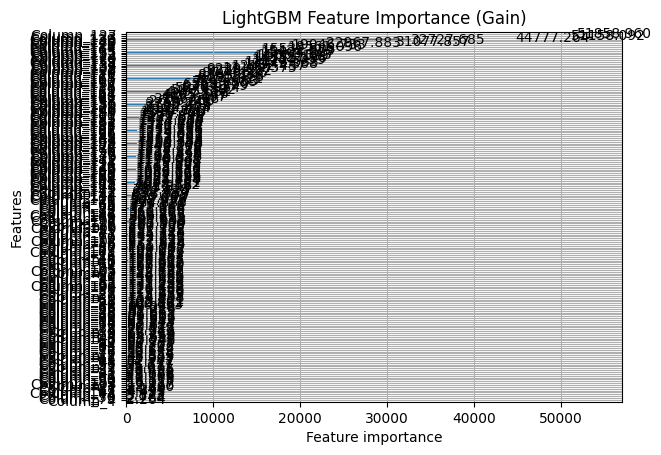

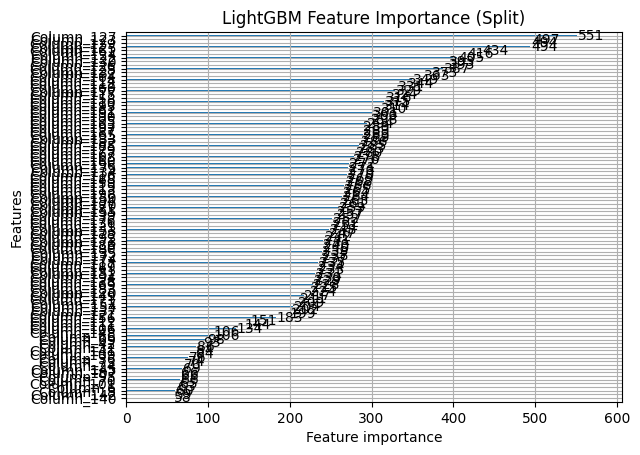

98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[LightGBM] [Warning] feature_fraction is set=0.48671265951426684, colsample_bytree=0.6153816025830104 will be ignored. Current value: feature_fraction=0.48671265951426684
[LightGBM] [Warning] bagging_fraction is set=0.6729240029456464, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6729240029456464
[LightGBM] [Warning] feature_fraction is set=0.48671265951426684, colsample_bytree=0.6153816025830104 will be ignored. Current value: feature_fraction=0.48671265951426684
[LightGBM] [Warning] bagging_fraction is set=0.6729240029456464, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6729240029456464
Meta Model Final log loss: 0.17265623008030317
Meta Model Final log loss: 0.8453450978770098


'\n# transform, predict and save final data\nX_final = pd.read_csv("final_data_swc.csv")\ntrain_data.drop(columns=[\'x_51\', \'x_82\'])\nX_final = X_final.drop(to_drop, axis=1)\nX_final = scaler.transform(X_final)\n\nrf_final_probs = rf.predict_proba(X_final)\nnn_final_probs = nn.predict(X_final)\nae_final_features = autoencoder.predict(X_final)\nstacked_features_final = np.column_stack((rf_final_probs, nn_final_probs, ae_final_features))\nstacked_features_final = normalize(stacked_features_final, axis=1, norm=\'l2\')\n\npreds_final = meta_model.predict_proba(stacked_features_final)\npd.DataFrame(preds_final).to_csv("preds_final.csv", sep=\',\')\n'

In [ ]:
### main ###

#!pip install bayesian-optimization
#!pip install optuna_integration
#!pip install seaborn
#!pip install matplotlib
#!pip install pytorch-tabnet


import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, scale, normalize, QuantileTransformer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import log_loss, confusion_matrix
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier, plot_importance
from keras import metrics, regularizers
from keras.models import Sequential, Model, load_model
from keras.layers import Dense, GaussianNoise, Input, Dropout
from keras.optimizers import Adam
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sn
import matplotlib.pyplot as plt
import optuna
from pytorch_tabnet.tab_model import TabNetClassifier

import warnings
warnings.filterwarnings("ignore")


ae_epoch, nn_epoch, lg_max_iter, tn_max_epochs, optuna_n_trials = 200, 200, 400, 1000, 30
#ae_epoch, nn_epoch, lg_max_iter, tn_max_epochs, optuna_n_trials = 3, 3, 150, 3, 10

def calculate_vif(X, thresh=100):
    cols = X.columns
    variables = np.arange(X.shape[1])
    dropped=True
    while dropped:
        dropped=False
        c = X[cols[variables]].values
        vif = [variance_inflation_factor(c, ix) for ix in np.arange(c.shape[1])]

        maxloc = vif.index(max(vif))
        if max(vif) > thresh:
            print('dropping \'' + X[cols[variables]].columns[maxloc] + '\' at index: ' + str(maxloc))
            variables = np.delete(variables, maxloc)
            dropped=True

    print('Remaining variables:')
    print(X.columns[variables])
    return X[cols[variables]]


def remove_highly_correlated_features(df, threshold=0.96):
    # Calculate the correlation matrix
    corr_matrix = df.corr().abs()

    # Select upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Find index of feature columns with correlation greater than the threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    # Drop features
    reduced_df = df.drop(columns=to_drop)

    return reduced_df, to_drop


def get_autoencoder(data):
    input_dim = data.shape[1]
    nb_epoch = ae_epoch
    batch_size = 32
    learning_rate = 1e-4

    input_layer = Input(shape=(input_dim, ))
    encoder = Dense(64, activation="elu",
                    activity_regularizer=regularizers.l1(10e-5))(input_layer)
    encoder = Dense(32, activation="elu")(encoder)
    decoder = Dense(32, activation='elu')(encoder)
    decoder = Dense(64, activation='elu')(decoder)
    output_layer = Dense(input_dim, activation='elu')(decoder)
    autoencoder = Model(inputs=input_layer, outputs=output_layer)

    autoencoder.compile(optimizer='adam',
                        loss='mean_squared_error',
                        metrics=['accuracy'])
    autoencoder.fit(data, data,
                        epochs=nb_epoch,
                        batch_size=batch_size,
                        shuffle=True,
                        verbose=1)

    autoencoder_trimmed = Sequential()
    for layer in autoencoder.layers[:-3]:
        autoencoder_trimmed.add(layer)
    print(autoencoder_trimmed.summary())

    return autoencoder_trimmed


train_data = pd.read_csv(r"C:\Users\moses_y\OneDrive\Desktop\ML Projects\Log Loss\train_data_swc.csv")
train_data.dropna()
#train_data.drop(columns=['x_51', 'x_82'])
train_data, to_drop = remove_highly_correlated_features(train_data)
print(to_drop)

X = train_data.iloc[:, :-1]
y = train_data.iloc[:, -1]

unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

#a,b,c,d,e,f,g = X.sum(axis=1), X.mean(axis=1), X.median(axis=1), X.std(axis=1), X.kurtosis(axis=1), X.skew(axis=1), X.isin([0]).sum(axis=1)
X["g_sum"] = X.sum(axis=1)
X["g_mean"] = X.mean(axis=1)
X["g_median"] = X.median(axis=1)
X["g_std"] = X.std(axis=1)
X["g_kurt"] = X.kurtosis(axis=1)
X["g_skew"] = X.skew(axis=1)
X["g_zeros"] = X.isin([0]).sum(axis=1)

X_train, X_temp, y_train, y_temp = train_test_split(X, y-1, test_size=0.2, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.fit_transform(X_valid)
X_test = scaler.fit_transform(X_test)

X_train_original, X_valid_original, X_test_original = X_train, X_valid, X_test

# Define base models
rf = RandomForestClassifier(n_estimators=158, random_state=42)
et = ExtraTreesClassifier()
kn = KNeighborsClassifier()
lg = LogisticRegression(max_iter=lg_max_iter)
tn = TabNetClassifier()

# Neural Network
nn = Sequential([
    GaussianNoise(0.01),
    Dense(512, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.29),
    Dense(256, activation='swish'),
    Dropout(0.29),
    Dense(128, activation='sigmoid', input_dim=X_train.shape[1]),
    Dropout(0.29),
    Dense(len(np.unique(y)), activation='softmax')
])
nn.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy')

# Train base models
tn.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], patience=50, batch_size=1024, virtual_batch_size=128, eval_metric=['logloss'], max_epochs=tn_max_epochs)

nn.fit(X_train, y_train, epochs=nn_epoch, batch_size=32, verbose=1, validation_data=(X_valid, y_valid))

rf.fit(X_train, y_train)
probs = rf.predict_proba(X_train)
print(f"Random Forest log loss: {log_loss(y_train, probs)}")
probs = rf.predict_proba(X_test)
print(f"Random Forest log loss: {log_loss(y_test, probs)}")

et.fit(X_train, y_train)
probs = et.predict_proba(X_train)
print(f"extra trees log loss: {log_loss(y_train, probs)}")
probs = et.predict_proba(X_test)
print(f"extra trees log loss: {log_loss(y_test, probs)}")
feature_importance = et.feature_importances_
feature_importance_normalized = np.std([tree.feature_importances_ for tree in
                                        et.estimators_],
                                        axis = 0)
print(feature_importance_normalized)

kn.fit(X_train, y_train)
probs = kn.predict_proba(X_train)
print(f"KN Final log loss: {log_loss(y_train, probs)}")
probs = kn.predict_proba(X_test)
print(f"KN Final log loss: {log_loss(y_test, probs)}")

lg.fit(X_train, y_train)
probs = lg.predict_proba(X_train)
print(f"LR Final log loss: {log_loss(y_train, probs)}")
probs = lg.predict_proba(X_test)
print(f"LR Final log loss: {log_loss(y_test, probs)}")
autoencoder = get_autoencoder(X_train)

# Predict probabilities on validation set
rf_probs = rf.predict_proba(X_valid)
nn_probs = nn.predict(X_valid)
et_probs = et.predict_proba(X_valid)
kn_probs = kn.predict_proba(X_valid)
lg_probs = lg.predict_proba(X_valid)
tn_probs = tn.predict_proba(X_valid)
ae_features = autoencoder.predict(X_valid)

# Stack predictions
stacked_features_valid = np.column_stack((X_valid, rf_probs, nn_probs, et_probs, kn_probs, lg_probs, tn_probs, ae_features))
print(stacked_features_valid)
#stacked_features_valid = normalize(stacked_features_valid, axis=1, norm='l2')

# Define the objective function for Optuna
def objective(trial):
    param = {
        'objective': 'multiclass',
        'num_class': 9,
        'metric': 'multi_logloss',
        'boosting_type': 'gbdt',
        'verbose': -1,
        #'lambda_l1': trial.suggest_loguniform('lambda_l1', 1e-8, 10.0),
        #'lambda_l2': trial.suggest_loguniform('lambda_l2', 1e-8, 10.0),
        #'num_leaves': trial.suggest_int('num_leaves', 16, 256),
        'feature_fraction': trial.suggest_uniform('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.4, 1.0),
        #'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        #'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        #"subsample": trial.suggest_float("subsample", 0.05, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.05, 1.0),
        #"min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 100),
    }
    lgbm = LGBMClassifier(**param)
    return cross_val_score(lgbm, stacked_features_valid, y_valid, n_jobs=-1, cv=3, scoring='neg_log_loss').mean()

# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=optuna_n_trials)

# Train the final model with the best hyperparameters
params = study.best_params
meta_model = LGBMClassifier(**params)
meta_model.fit(stacked_features_valid, y_valid)
plot_importance(meta_model, max_num_features=250, importance_type="gain", title="LightGBM Feature Importance (Gain)")
plt.show()
plot_importance(meta_model, max_num_features=100, importance_type="split", title="LightGBM Feature Importance (Split)")
plt.show()

# Generate stacked features for the test set
rf_test_probs = rf.predict_proba(X_test)
nn_test_probs = nn.predict(X_test)
et_test_probs = et.predict_proba(X_test)
kn_test_probs = kn.predict_proba(X_test)
lg_test_probs = lg.predict_proba(X_test)
tn_test_probs = tn.predict_proba(X_test)
ae_test_features = autoencoder.predict(X_test)

stacked_features_test = np.column_stack((X_test, rf_test_probs, nn_test_probs, et_test_probs, kn_test_probs, lg_test_probs, tn_test_probs, ae_test_features))
stacked_features_test = normalize(stacked_features_test, axis=1, norm='l2')

# Final validation
preds_valid = meta_model.predict_proba(stacked_features_valid)
preds_test = meta_model.predict_proba(stacked_features_test)
print(f"Meta Model Final log loss: {log_loss(y_valid, preds_valid)}")
print(f"Meta Model Final log loss: {log_loss(y_test, preds_test)}")

"""
# transform, predict and save final data
X_final = pd.read_csv("final_data_swc.csv")
train_data.drop(columns=['x_51', 'x_82'])
X_final = X_final.drop(to_drop, axis=1)
X_final = scaler.transform(X_final)

rf_final_probs = rf.predict_proba(X_final)
nn_final_probs = nn.predict(X_final)
ae_final_features = autoencoder.predict(X_final)
stacked_features_final = np.column_stack((rf_final_probs, nn_final_probs, ae_final_features))
stacked_features_final = normalize(stacked_features_final, axis=1, norm='l2')

preds_final = meta_model.predict_proba(stacked_features_final)
pd.DataFrame(preds_final).to_csv("preds_final.csv", sep=',')
"""

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
import optuna

# Load data
data = pd.read_csv(r"C:\Users\moses_y\OneDrive\Desktop\ML Projects\Log Loss\train_data_swc.csv").dropna()
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
y -= 1  # Ensure labels start from 0 for 'multi:softprob'

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

# Feature Engineering: PCA for dimensionality reduction
pca = PCA(n_components=0.95)  # retain 95% variance
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

# Handling class imbalance with SMOTE
smote = SMOTE()
X_train_sm, y_train_sm = smote.fit_resample(X_train_pca, y_train)

# GridSearchCV to find the best hyperparameters
params = {
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1]
}

xgb = XGBClassifier(objective='multi:softprob', num_class=len(np.unique(y)))
grid = GridSearchCV(xgb, params, scoring='neg_log_loss', cv=3, n_jobs=-1)
grid.fit(X_train_sm, y_train_sm)

best_xgb = grid.best_estimator_
probs = best_xgb.predict_proba(X_valid_pca)
print(f"Optimized XGBoost Log Loss: {log_loss(y_valid, probs)}")

# Optuna for further optimization
def objective(trial):
    param = {
        'verbosity': 0,
        'objective': 'multi:softprob',
        'num_class': len(np.unique(y)),
        'booster': trial.suggest_categorical('booster', ['gbtree', 'dart']),
        'lambda': trial.suggest_loguniform('lambda', 1e-3, 10.0),
        'alpha': trial.suggest_loguniform('alpha', 1e-3, 10.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'eta': trial.suggest_float('eta', 1e-3, 0.1),
        'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide'])
    }
    model = XGBClassifier(**param)
    model.fit(X_train_sm, y_train_sm, eval_set=[(X_valid_pca, y_valid)], verbose=False, early_stopping_rounds=30)
    preds = model.predict_proba(X_valid_pca)
    return log_loss(y_valid, preds)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

best_params = study.best_trial.params
print("Best parameters:", best_params)
